-------------------------------------------------------------------------------

## **Business Problem Statement**: A telecommunications company is facing high customer churn rates, which are impacting revenue and customer retention. The company wants to identify factors contributing to churn and develop strategies to reduce it.

-------------------------------------------------------------------------------

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

In [2]:
customer_data = pd.read_csv("customer_churn_data.csv")

In [3]:
customer_data.head(10)

,CustomerID,Age,Location,PlanType,AverageCallDuration,DataUsage,NumberOfCalls,MonthlyCharges,PaymentMethod,ChurnStatus
0,C0001,56,Urban,Basic,26.289402,8.821847,135,69.987056,BankTransfer,No
1,C0002,69,Rural,Basic,16.289559,24.010073,235,65.104664,CreditCard,No
2,C0003,46,Urban,Basic,19.343779,3.233515,230,76.134922,BankTransfer,Yes
3,C0004,32,Suburban,Basic,19.689638,47.147981,220,121.631377,BankTransfer,No
4,C0005,60,Rural,Basic,24.774136,4.203650,34,82.942494,CreditCard,Yes
5,C0006,25,Urban,Basic,10.668812,22.203607,25,123.221879,CreditCard,Yes
6,C0007,78,Urban,Basic,22.258485,26.729122,191,94.943557,BankTransfer,No
7,C0008,38,Urban,Basic,16.328765,49.272540,138,64.469027,BankTransfer,No
8,C0009,56,Urban,Premium,24.008426,8.718080,51,125.297237,BankTransfer,No
9,C0010,75,Urban,Basic,29.725835,6.164360,245,50.977657,BankTransfer,Yes


-------------------------------------------------------------------------------
## 1. Summary of the Data
This dataset contains information on 1,000 telecommunications customers. It includes demographic details (such as Age and Location), subscription information (PlanType and PaymentMethod), usage metrics (AverageCallDuration, DataUsage, and NumberOfCalls), and billing information (MonthlyCharges). The target variable, ChurnStatus, indicates whether a customer has churned (Yes/No)

--------------------------------------------------------------------------------

## 2. Column Descriptions

* `CustomerID`: A unique identifier for each customer, similar to a membership number.
* `Age`: The customer’s age in years.
* `Location`: Indicates whether a customer lives in an Urban, Rural, or Suburban area.
* `PlanType`: Shows the type of subscription plan—Basic or Premium.
* `AverageCallDuration`: The average length of calls made by the customer, measured in minutes.
* `DataUsage`: Total amount of data used by the customer, in gigabytes.
* `NumberOfCalls`: How many calls the customer makes in a month.
* `MonthlyCharges`: The amount billed each month.
* `PaymentMethod`: The method used to pay the bill, either via Credit Card or Bank Transfer.
* `ChurnStatus`: Indicates if a customer has left (Yes) or stayed (No).




-------------------------------------------------------------------------------
### Issue with the Dataset
- After manual testing,I saw that the Column AverageCallDuration contains some Rows with text and some with numeric values.
- incorrect data type assigned to PlanType, PaymentMethod ChurnStatus
-------------------------------------------------------------------------------

In [4]:
customer_data.tail()

,CustomerID,Age,Location,PlanType,AverageCallDuration,DataUsage,NumberOfCalls,MonthlyCharges,PaymentMethod,ChurnStatus
995,C0996,18,Urban,Basic,26.864900,18.401531,26,95.678824,CreditCard,No
996,C0997,35,Suburban,Premium,9.875492,6.706080,295,66.380164,CreditCard,No
997,C0998,49,Urban,Premium,17.004437,13.053832,212,41.355158,CreditCard,No
998,C0999,64,Suburban,Premium,23.892873,32.283282,108,85.483526,CreditCard,No
999,C1000,66,Rural,Basic,13.070324,14.139060,288,127.926375,BankTransfer,Yes


In [5]:
customer_data.sample(5)

,CustomerID,Age,Location,PlanType,AverageCallDuration,DataUsage,NumberOfCalls,MonthlyCharges,PaymentMethod,ChurnStatus
908,C0909,78,Urban,Basic,13.029638,3.023256,274,129.678469,BankTransfer,No
74,C0075,64,Urban,Basic,4.478657,25.888404,215,29.446526,CreditCard,No
507,C0508,34,Urban,Basic,29.479437,2.742085,272,107.004878,CreditCard,No
218,C0219,62,Urban,Basic,19.693144,32.552065,65,140.712219,CreditCard,No
747,C0748,52,Urban,Premium,12.835453,20.148925,263,148.586291,CreditCard,No


In [6]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           1000 non-null   object 
 1   Age                  1000 non-null   int64  
 2   Location             1000 non-null   object 
 3   PlanType             1000 non-null   object 
 4   AverageCallDuration  1000 non-null   float64
 5   DataUsage            1000 non-null   float64
 6   NumberOfCalls        1000 non-null   int64  
 7   MonthlyCharges       1000 non-null   float64
 8   PaymentMethod        1000 non-null   object 
 9   ChurnStatus          1000 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 78.3+ KB


Checking if the Data have duplicate values

In [7]:
customer_data.duplicated().sum()

0

Checking the specific column CustomerID to check if it have duplicate value or not fortunatly we dont have a duplicate value

In [8]:
customer_data['CustomerID'].duplicated().sum()

0

In [9]:
customer_data.describe()

,Age,AverageCallDuration,DataUsage,NumberOfCalls,MonthlyCharges
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.857000,16.075521,24.501223,150.261000,84.296789
std,18.114267,8.236725,14.403498,83.508038,37.415142
min,18.000000,1.012841,0.509233,10.000000,20.509389
25%,35.000000,9.199405,11.979636,79.750000,51.639004
50%,50.000000,16.653440,23.997300,149.000000,83.955434
75%,66.000000,23.116538,37.070607,221.000000,115.935954
max,79.000000,29.986774,49.882330,299.000000,149.929889


- Checked the Age of the Customers if they are of legal Age
- The minimum Age of the Customer is 18 which is Valid
-The maximum Age of of the customer in Dataset is 79

In [10]:
customer_data[customer_data['AverageCallDuration'] == 1.0128406616790286]

,CustomerID,Age,Location,PlanType,AverageCallDuration,DataUsage,NumberOfCalls,MonthlyCharges,PaymentMethod,ChurnStatus
312,C0313,69,Suburban,Basic,1.012841,29.035386,221,138.928543,BankTransfer,No


-------------------------------------------------------------------------------

After Descriptive Analysis I saw a sudden jump in the column NumberofCalls where we can clearly see min is around 10 while the 25 percentile is 79 this does indicate possible outliers

--------------------------------------------------------------------------------


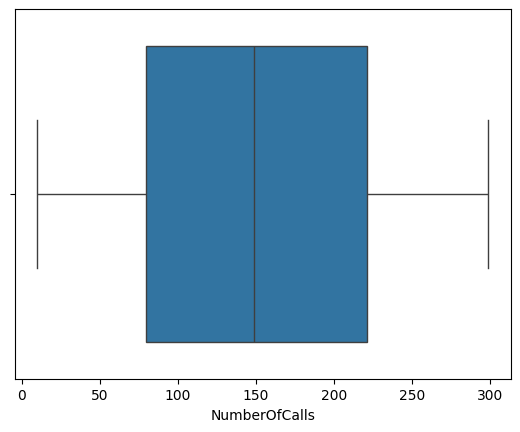

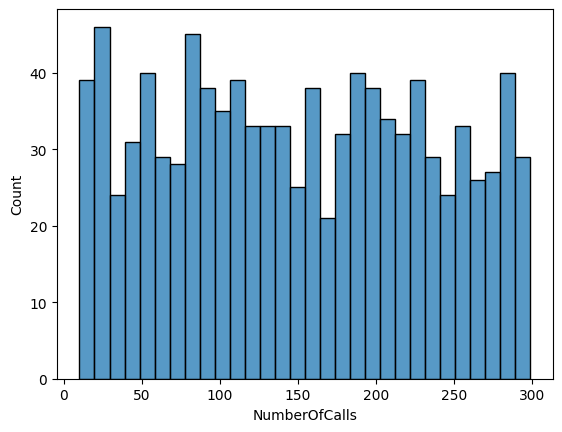

In [11]:
sns.boxplot(x=customer_data['NumberOfCalls'])
plt.show()
sns.histplot(customer_data['NumberOfCalls'], bins=30)
plt.show()

-------------------------------------------------------------------------------
# Data Cleaning

### I converted PlanType, PaymentMethod, and ChurnStatus to categorical types to improve memory efficiency and ensure that these columns are treated as nominal features
--------------------------------------------------------------------------------

In [12]:
customer_data['PlanType'] = customer_data['PlanType'].astype('category')
customer_data['PaymentMethod'] = customer_data['PaymentMethod'].astype('category')
customer_data['ChurnStatus'] = customer_data['ChurnStatus'].astype('category')

In [13]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   CustomerID           1000 non-null   object  
 1   Age                  1000 non-null   int64   
 2   Location             1000 non-null   object  
 3   PlanType             1000 non-null   category
 4   AverageCallDuration  1000 non-null   float64 
 5   DataUsage            1000 non-null   float64 
 6   NumberOfCalls        1000 non-null   int64   
 7   MonthlyCharges       1000 non-null   float64 
 8   PaymentMethod        1000 non-null   category
 9   ChurnStatus          1000 non-null   category
dtypes: category(3), float64(3), int64(2), object(2)
memory usage: 58.1+ KB


--------------------------------------------------------------------------------
# EDA

# Checking the Percentage of customer churn rate
--------------------------------------------------------------------------------

In [14]:
churn_percentage = customer_data['ChurnStatus'].value_counts(normalize=True) * 100
print(churn_percentage)

ChurnStatus
No     78.5
Yes    21.5
Name: proportion, dtype: float64


### Column Types
* Numerical - Age, AverageCallDuration, DataUsage, NumberofCalls, MonthlyCharges
* Categorical - Location, PlanType, PaymentMethod, ChurnStatus
* Mixed - CustomerID

### Performing Univariate Analysis on Numerical Columns

### Age

conclusions

* Minimum age is 18 while Max age is 79 while the frequency of old customer is more.
* Age is like slighly left skewed but its close to 0
* Age Column Does not have any missing values

In [15]:
customer_data['Age'].describe()

,Age
count,1000.000000
mean,49.857000
std,18.114267
min,18.000000
25%,35.000000
50%,50.000000
75%,66.000000
max,79.000000


<Axes: ylabel='Frequency'>

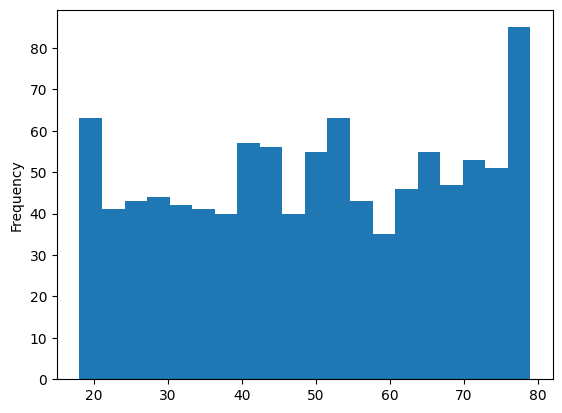

In [16]:
customer_data['Age'].plot(kind='hist', bins=20)

<Axes: ylabel='Density'>

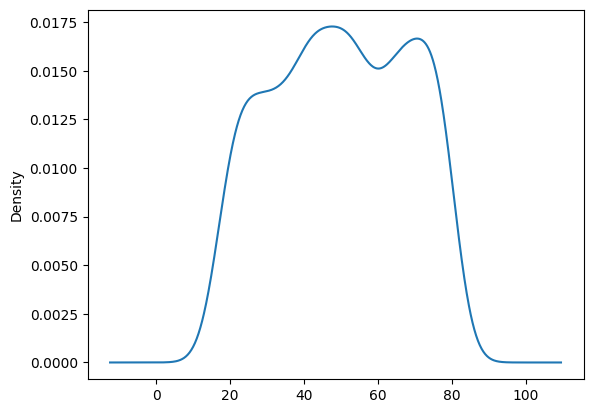

In [17]:
customer_data['Age'].plot(kind='kde')

In [18]:
customer_data['Age'].skew()

-0.06575522501530556

<Axes: >

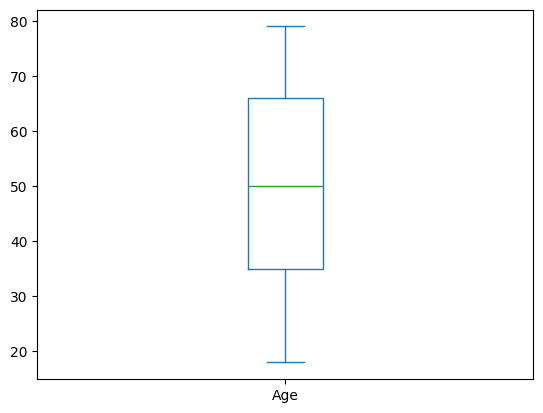

In [ ]:
customer_data['Age'].plot(kind='box')

In [19]:
customer_data['Age'].isnull().sum()

0

### AverageCallDuration

Conclusions

* The minimum average call duration is about 1.01 minutes, while the maximum is around 29.99 minutes.
* The distribution is nearly symmetric but it has a slight left skew (skewness ≈ -0.14), indicating most call durations are clustered around the center.
* There are no missing values in the AverageCallDuration column.

In [20]:
customer_data['AverageCallDuration'].describe()

,AverageCallDuration
count,1000.000000
mean,16.075521
std,8.236725
min,1.012841
25%,9.199405
50%,16.653440
75%,23.116538
max,29.986774


<Axes: ylabel='Frequency'>

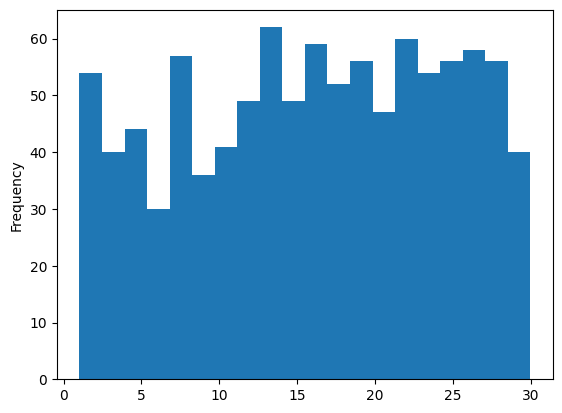

In [21]:
customer_data['AverageCallDuration'].plot(kind='hist', bins=20)

Text(0, 0.5, 'Frequency')

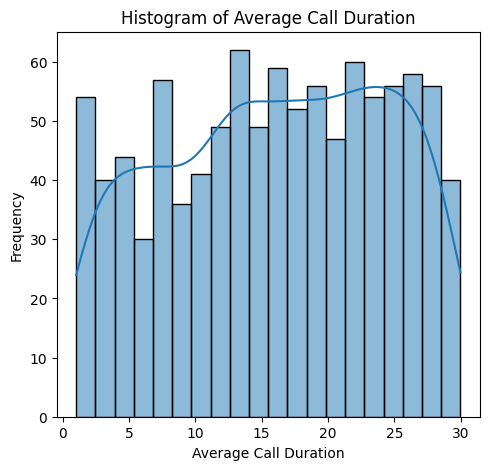

In [22]:
plt.figure(figsize=(12, 5))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(customer_data['AverageCallDuration'], kde=True, bins=20)
plt.title("Histogram of Average Call Duration")
plt.xlabel("Average Call Duration")
plt.ylabel("Frequency")


<Axes: ylabel='Density'>

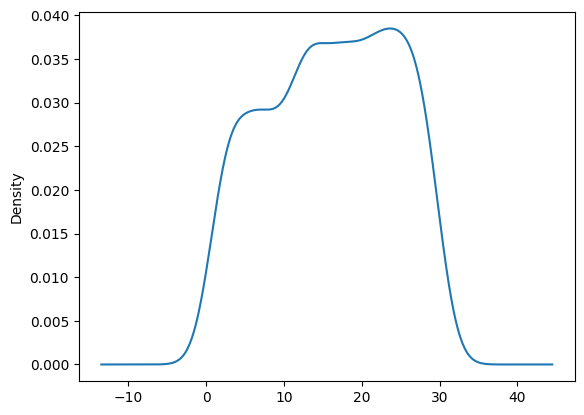

In [23]:
customer_data['AverageCallDuration'].plot(kind='kde')

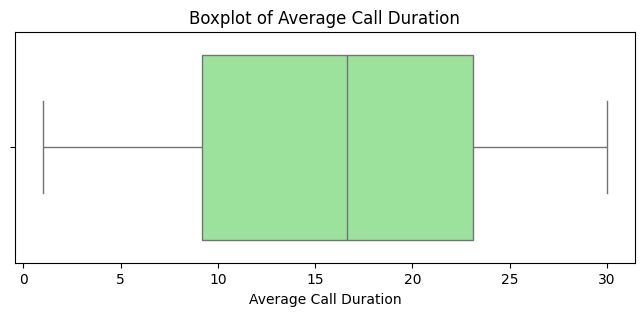

In [ ]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=customer_data['AverageCallDuration'], color='lightgreen')
plt.title("Boxplot of Average Call Duration")
plt.xlabel("Average Call Duration")
plt.show()

In [ ]:
customer_data['AverageCallDuration'].skew()

-0.13977923359349292

# DataUsage

* conclusions

* Minimum Data usage is around 0.51 MB, while the maximum is nearly 49.88 GB.
* The mean (24.50 GB) is close to the median (23.99 GB) which suggests the distribution is almost symmetric.
* The skew is slightly positive 0.07, indicating a very small tail to the right.
* There are no missing values in this column.

In [ ]:
customer_data['DataUsage'].describe()

,DataUsage
count,1000.000000
mean,24.501223
std,14.403498
min,0.509233
25%,11.979636
50%,23.997300
75%,37.070607
max,49.882330


<Axes: ylabel='Frequency'>

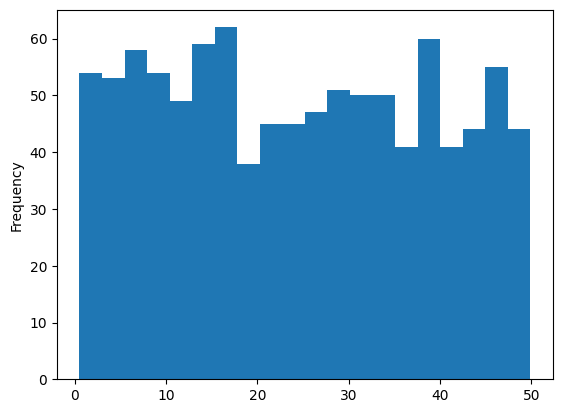

In [ ]:
customer_data['DataUsage'].plot(kind='hist', bins=20)

<Axes: ylabel='Density'>

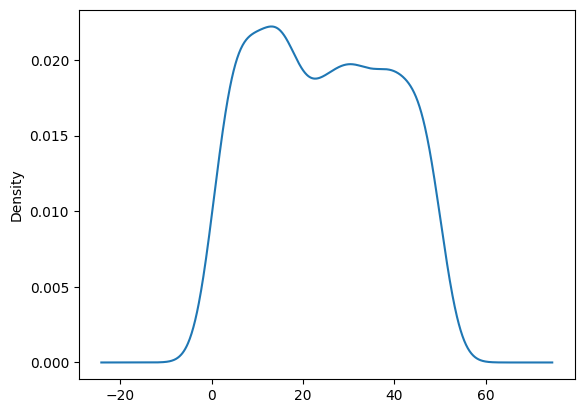

In [ ]:
customer_data['DataUsage'].plot(kind='kde')

In [ ]:
customer_data['DataUsage'].skew()

0.07365520427410582

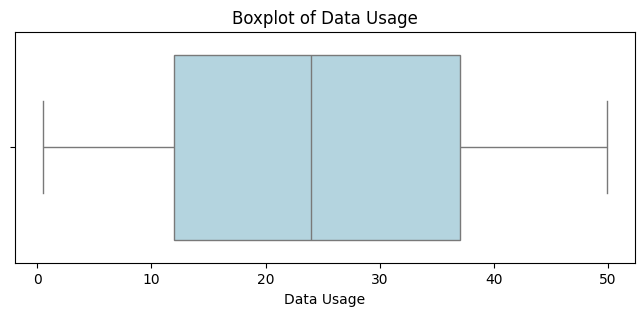

In [ ]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=customer_data['DataUsage'], color='lightblue')
plt.title("Boxplot of Data Usage")
plt.xlabel("Data Usage")
plt.show()

In [ ]:
customer_data['DataUsage'].isnull().sum()

0

### NumberofCalls

conclusions
* Minimum is 10 calls, but the 25th percentile is already 80 calls, indicating a small group of very low-call customers while Maximum is 299 calls, which reflects wide range of calling behaviour
* The mean (150.26) is close to the median (149), suggesting a reasonably balanced distribution overall.
* The standard deviation (83.51) is high, pointing to significant variability.
* The skew is slightly positive 0.5), meaning there’s a mild right tail.
* There are no missing values in this column.

In [ ]:
customer_data['NumberOfCalls'].describe()

,NumberOfCalls
count,1000.000000
mean,150.261000
std,83.508038
min,10.000000
25%,79.750000
50%,149.000000
75%,221.000000
max,299.000000


<Axes: ylabel='Frequency'>

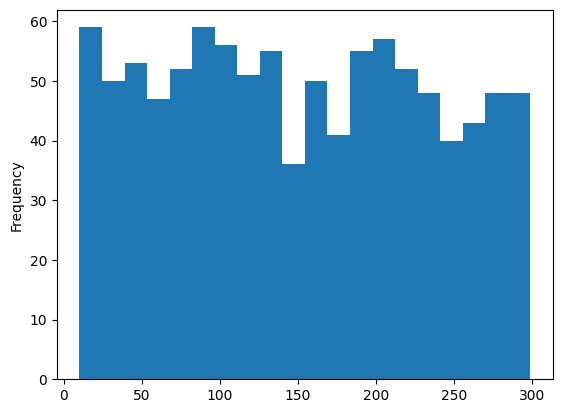

In [ ]:
customer_data['NumberOfCalls'].plot(kind='hist', bins=20)

<Axes: ylabel='Density'>

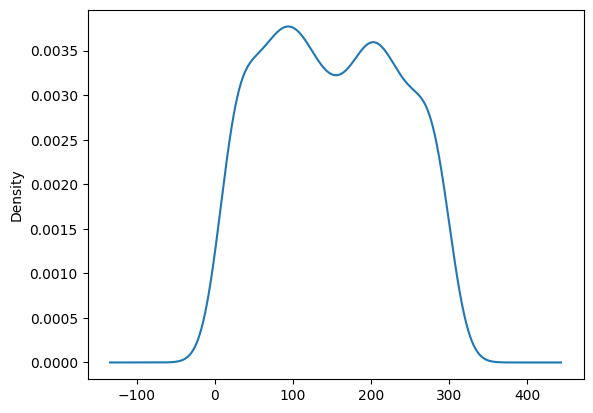

In [ ]:
customer_data['NumberOfCalls'].plot(kind='kde')

In [ ]:
customer_data['NumberOfCalls'].skew()

0.05581428142233308

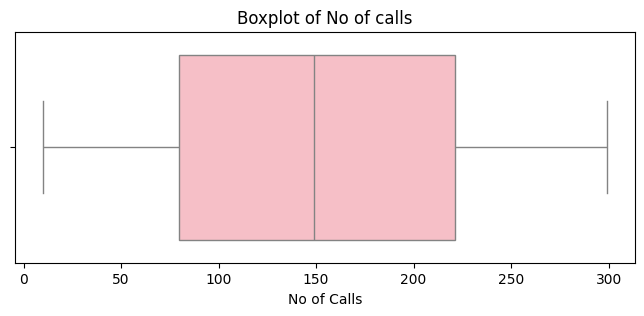

In [ ]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=customer_data['NumberOfCalls'], color='lightpink')
plt.title("Boxplot of No of calls")
plt.xlabel("No of Calls")
plt.show()

In [ ]:
customer_data['NumberOfCalls'].isnull().sum()

0

### MonthlyCharges

conclusions

* The Minimum Monthly Charges are 20.50 dollars ,while the Maximum is 149 dollars indicating wide range of billing amount
* The mean 84.30 is close to the median 83.95, suggesting a nearly symmetric distribution.
* The skew is slightly positive 0.04, indicating a minor right tail.
* There are no missing values in this column

In [ ]:
customer_data['MonthlyCharges'].describe()

,MonthlyCharges
count,1000.000000
mean,84.296789
std,37.415142
min,20.509389
25%,51.639004
50%,83.955434
75%,115.935954
max,149.929889


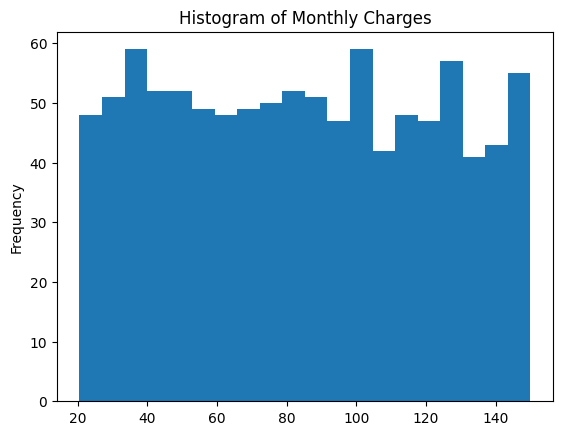

In [ ]:
customer_data['MonthlyCharges'].plot(kind='hist', bins=20)
plt.title("Histogram of Monthly Charges")
plt.show()

<Axes: ylabel='Density'>

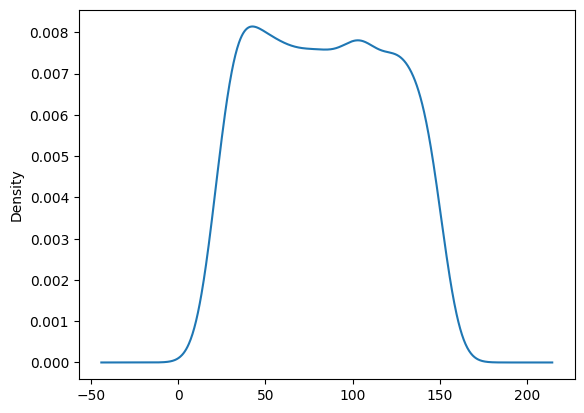

In [ ]:
customer_data['MonthlyCharges'].plot(kind='kde')

In [ ]:
customer_data['MonthlyCharges'].skew()

0.03985573607879083

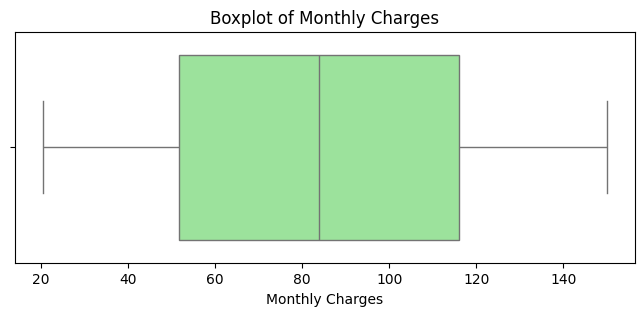

In [ ]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=customer_data['MonthlyCharges'], color='lightgreen')
plt.title("Boxplot of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.show()

In [ ]:
customer_data['MonthlyCharges'].isnull().sum()

0

# Univariate Analysis on Categorial columns

* Categorical - Location, PlanType, PaymentMethod, ChurnStatus

### Location

**conclusions**

* So Approximately 47% of customers are in Urban areas, 33.3% in Rural, and 19.7% in Suburban areas This indicates that almost half of your customer base is urban, suggesting that service is most heavily used in city environments, while a significant portion still comes from rural and suburban regions

In [ ]:
customer_data['Location'].value_counts()

,count
Location,
Urban,470
Rural,333
Suburban,197


<Axes: xlabel='Location'>

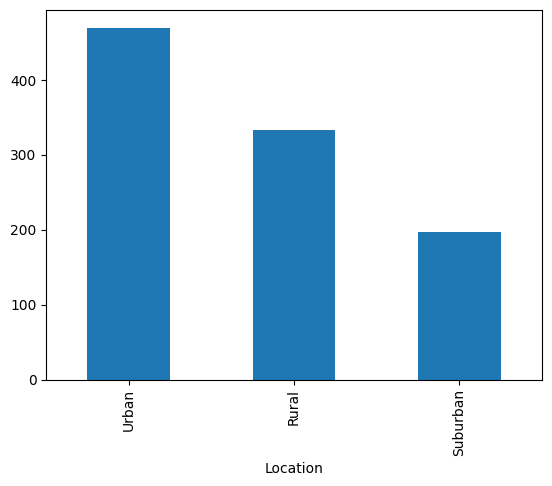

In [ ]:
customer_data['Location'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

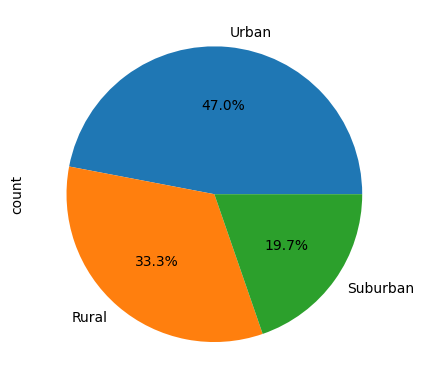

In [ ]:
customer_data['Location'].value_counts().plot(kind='pie', autopct ='%0.1f%%')

In [ ]:
customer_data['Location'].isnull().sum()

0

### PlanType

**conclusions**

* 71% of customers are on the Basic plan, while 29% are on the Premium plan
* So This may suggest that the majority of the customers prefer or are subscribed to the Basic plan, which may indicate that cost sensitivity is a factor
* No missing values present

In [ ]:
customer_data['PlanType'].value_counts()

,count
PlanType,
Basic,710
Premium,290


<Axes: ylabel='count'>

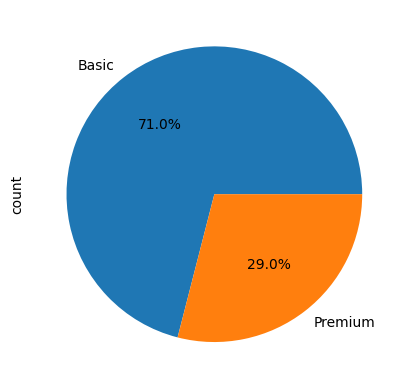

In [ ]:
customer_data['PlanType'].value_counts().plot(kind='pie', autopct ='%0.1f%%')

In [ ]:
customer_data['PlanType'].isnull().sum()

0

### PaymentMethod

**conclusions**

* Credit Card is used by about 62.1% of customers, while Bank Transfer is used by around 37.9%.
* This indicates that a majority of your customers prefer using a Credit Card for their payments.

In [ ]:
customer_data['PaymentMethod'].value_counts()

,count
PaymentMethod,
CreditCard,621
BankTransfer,379


<Axes: ylabel='count'>

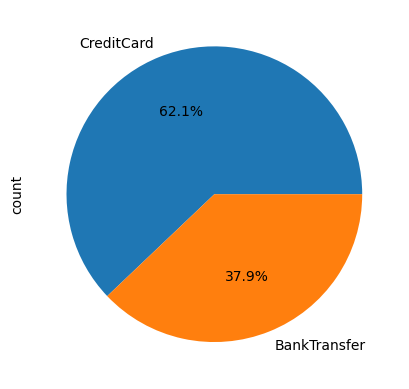

In [ ]:
customer_data['PaymentMethod'].value_counts().plot(kind='pie', autopct ='%0.1f%%')

In [ ]:
customer_data['PaymentMethod'].isnull().sum()

0

### ChurnStatus

**conclusions**

* Based on the pie chart for ChurnStatus, about 78.5% of customers have not churned ("No"), while 21.5% have churned ("Yes").
* This indicates that roughly one in five customers have left the service.

In [ ]:
customer_data['ChurnStatus'].value_counts()

,count
ChurnStatus,
No,785
Yes,215


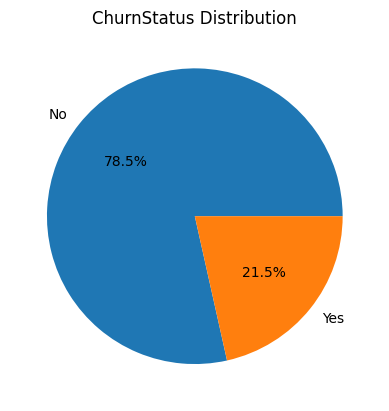

In [ ]:
customer_data['ChurnStatus'].value_counts().plot(kind='pie', autopct ='%0.1f%%')
plt.title('ChurnStatus Distribution')
plt.ylabel("")
plt.show()

In [ ]:
customer_data['ChurnStatus'].isnull().sum()

0

### Performing Bivariarte Analysis

In [ ]:
numeric_columns = customer_data.select_dtypes(include=['number'])
numeric_columns.corr()

,Age,AverageCallDuration,DataUsage,NumberOfCalls,MonthlyCharges
Age,1.000000,0.012033,0.026645,0.071916,0.004330
AverageCallDuration,0.012033,1.000000,-0.012588,-0.016946,0.041453
DataUsage,0.026645,-0.012588,1.000000,0.039853,0.032172
NumberOfCalls,0.071916,-0.016946,0.039853,1.000000,-0.024651
MonthlyCharges,0.004330,0.041453,0.032172,-0.024651,1.000000


### Churn Status vs Location

**conclusions**

* The churn rate across different locations is quite similar
Urban customers have the lowest churn rate 20.2%, while rural customers have the highest 23.1%
* Overall, the differences in churn rates by location are relatively small, suggesting that location may not be a strong factor driving churn in the data

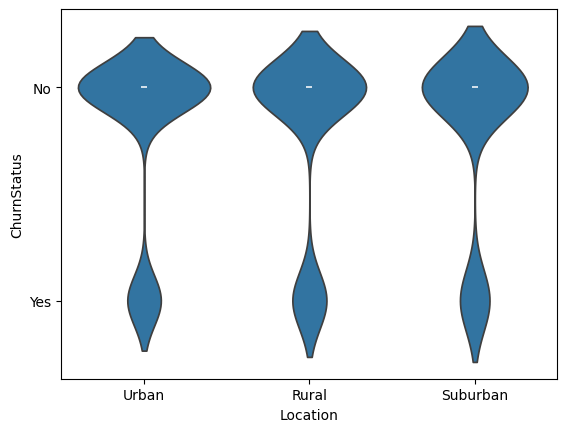

In [ ]:
sns.violinplot(data=customer_data, x='Location', y='ChurnStatus')
plt.show()

In [ ]:
pd.crosstab(customer_data['ChurnStatus'], customer_data['Location'], normalize='columns')*100

Location,Rural,Suburban,Urban
ChurnStatus,,,
No,76.876877,78.172589,79.787234
Yes,23.123123,21.827411,20.212766


<Axes: xlabel='ChurnStatus', ylabel='Location'>

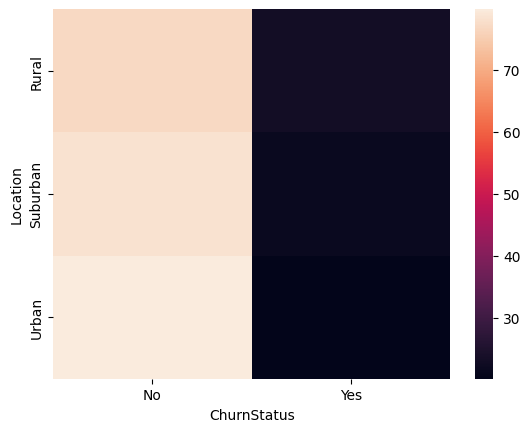

In [ ]:
sns.heatmap(pd.crosstab(customer_data['Location'], customer_data['ChurnStatus'], normalize='index')*100)

### ChurnStatus vs PlanType

**conclusions**
* For both Basic and Premium plan types, approximately 78% of customers did not churn, and about 22% churned.
* The churn rate is very similar between the two plan types, suggesting that the type of plan may not be a key differentiator in customer churn behavior

In [ ]:
pd.crosstab(customer_data['ChurnStatus'], customer_data['PlanType'], normalize='columns')*100

PlanType,Basic,Premium
ChurnStatus,,
No,78.591549,78.275862
Yes,21.408451,21.724138


<Axes: xlabel='ChurnStatus', ylabel='PlanType'>

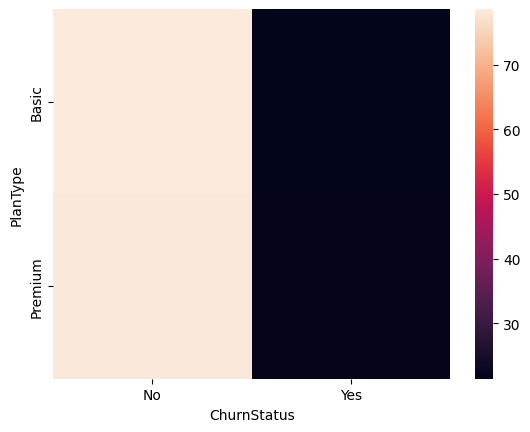

In [ ]:
sns.heatmap(pd.crosstab(customer_data['PlanType'], customer_data['ChurnStatus'], normalize='index')*100)

In [ ]:
contingency_table = pd.crosstab(customer_data['PlanType'], customer_data['ChurnStatus'])
print(contingency_table)

chi2, p ,dof, expected= chi2_contingency(contingency_table)
print("Chi-square Statistic:", chi2)
print("p-value:", p)

ChurnStatus   No  Yes
PlanType             
Basic        558  152
Premium      227   63
Chi-square Statistic: 0.0006474676210435318
p-value: 0.9796997107675653


### ChurnStatus vs PaymentMethod

In [ ]:
pd.crosstab(customer_data['PaymentMethod'], customer_data['ChurnStatus'], normalize='index')*100

ChurnStatus,No,Yes
PaymentMethod,,
BankTransfer,79.419525,20.580475
CreditCard,77.938808,22.061192


<Axes: xlabel='ChurnStatus', ylabel='PaymentMethod'>

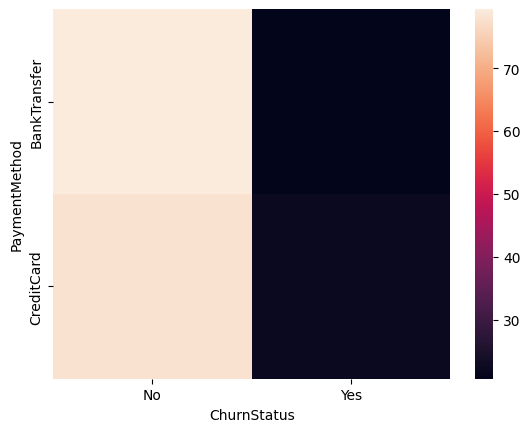

In [ ]:
sns.heatmap(pd.crosstab(customer_data['PaymentMethod'], customer_data['ChurnStatus'], normalize='index')*100)

### Location vs. PaymentMethod

**conclusion**

In [ ]:
pd.crosstab(customer_data['Location'], customer_data['PaymentMethod'], normalize='index')*100

PaymentMethod,BankTransfer,CreditCard
Location,,
Rural,36.636637,63.363363
Suburban,44.670051,55.329949
Urban,35.957447,64.042553


### Location vs. PlanType:

In [ ]:
pd.crosstab(customer_data['Location'], customer_data['PlanType'], normalize='index')*100

PlanType,Basic,Premium
Location,,
Rural,73.273273,26.726727
Suburban,70.050761,29.949239
Urban,69.787234,30.212766


### ChurnStatus vs Age

**conclusions**

* For both churned and non-churned customers, the average age is quite similar (51 years for churned and 49.5 years for non-churned).
* The minimal difference in mean ages indicates that age alone would not be a key factor in determining churn behavior.

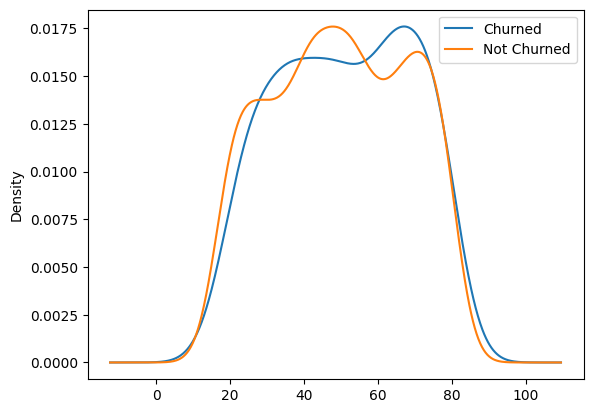

In [ ]:
# Churnstatus and Age

customer_data[customer_data['ChurnStatus'] == 'Yes']['Age'].plot(kind='kde' ,label='Churned')
customer_data[customer_data['ChurnStatus'] == 'No']['Age'].plot(kind='kde' ,label='Not Churned')
plt.legend()
plt.show()

In [ ]:
churned_age_mean = customer_data.loc[customer_data['ChurnStatus'] == 'Yes', 'Age'].mean()
not_churned_age_mean = customer_data.loc[customer_data['ChurnStatus'] == 'No', 'Age'].mean()
print(churned_age_mean, not_churned_age_mean)

50.967441860465115 49.55286624203821


### Performing T test

* t-test shows the difference in mean ages between churned and non-churned customers which is not statistically significant, further supporting that age alone is not a strong predictor of churn

In [ ]:
churned_ages = customer_data.loc[customer_data['ChurnStatus'] == 'Yes', 'Age']
not_churned_ages = customer_data.loc[customer_data['ChurnStatus'] == 'No', 'Age']
t_stat, p_val = ttest_ind(churned_ages, not_churned_ages)
print('T-stat:', t_stat)
print('p-value:', p_val)

T-stat: 1.014532162239186
p-value: 0.31057478143961464


### ChurnStatus vs DataUsage

**conclusions**

* The average data usage for churned customers is about 24.08 GB, and 24.62 GB for non-churned customers
* These values are very similar, indicating that the overall data usage is nearly the same across both the groups
* DataUsage does not significantly differ between churned and non-churned customers, suggesting that data consumption is not a key factor in predicting churn

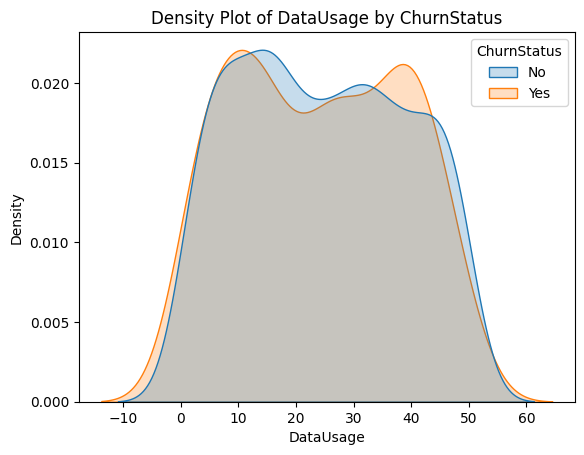

In [ ]:
#ChurnStatus and Data usage

sns.kdeplot(data=customer_data, x='DataUsage', hue='ChurnStatus', fill=True, common_norm=False)
plt.title('Density Plot of DataUsage by ChurnStatus')
plt.xlabel('DataUsage')
plt.ylabel('Density')
plt.show()

In [ ]:
churned_data_usage_mean = customer_data.loc[customer_data['ChurnStatus'] == 'Yes', 'DataUsage'].mean()
not_churned_data_usage_mean = customer_data.loc[customer_data['ChurnStatus'] == 'No', 'DataUsage'].mean()
print("Mean DataUsage (Churned):", churned_data_usage_mean)
print("Mean DataUsage (Not Churned):", not_churned_data_usage_mean)

Mean DataUsage (Churned): 24.082070436268438
Mean DataUsage (Not Churned): 24.616022533147834


**conclusions**

* The t-test resulted in a t-statistic of -0.48 and a p-value of 0.63.
* The high p-value (greater than 0.05) shows that the difference in mean data usage between churned and non-churned customers is not statistically significant


In [ ]:
churned_data_usage = customer_data.loc[customer_data['ChurnStatus'] == 'Yes', 'DataUsage']
not_churned_data_usage = customer_data.loc[customer_data['ChurnStatus'] == 'No', 'DataUsage']

t_stat, p_val = ttest_ind(churned_data_usage, not_churned_data_usage)
print("T-stat (DataUsage):", t_stat)
print("p-value (DataUsage):", p_val)

T-stat (DataUsage): -0.4814168768692341
p-value (DataUsage): 0.6303257813020406


### ChurnStatus vs AverageCallDuration

**conclusions**

 * The average call duration for churned customers is about 16.28 minutes, while for non-churned customers it is around 16.02 minutes—a very small difference

 * t-test confirms that this difference is not statistically significant p = 0.68, indicating that average call duration doesn't play a meaningful role in distinguishing between churned and non-churned customers

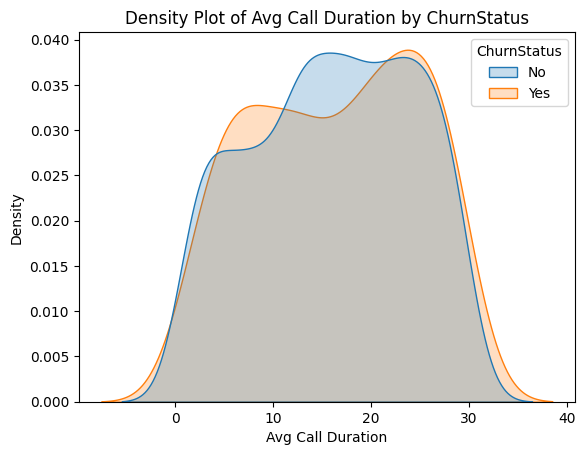

In [ ]:
#ChurnStatus and AverageCallDuration

sns.kdeplot(data=customer_data, x='AverageCallDuration', hue='ChurnStatus', fill=True, common_norm=False)
plt.title('Density Plot of Avg Call Duration by ChurnStatus')
plt.xlabel('Avg Call Duration')
plt.ylabel('Density')
plt.show()

In [ ]:
churned_data_usage_mean = customer_data.loc[customer_data['ChurnStatus'] == 'Yes', 'AverageCallDuration'].mean()
not_churned_data_usage_mean = customer_data.loc[customer_data['ChurnStatus'] == 'No', 'AverageCallDuration'].mean()
print("Mean AverageCallDuration (Churned):", churned_data_usage_mean)
print("Mean AverageCallDuration (Not Churned):", not_churned_data_usage_mean)

Mean AverageCallDuration (Churned): 16.284185953736625
Mean AverageCallDuration (Not Churned): 16.018370681726083


In [ ]:
churned_data_usage = customer_data.loc[customer_data['ChurnStatus'] == 'Yes', 'AverageCallDuration']
not_churned_data_usage = customer_data.loc[customer_data['ChurnStatus'] == 'No', 'AverageCallDuration']

t_stat, p_val = ttest_ind(churned_data_usage, not_churned_data_usage)
print("T-stat (AverageCallDuration):", t_stat)
print("p-value (AverageCallDuration):", p_val)

T-stat (AverageCallDuration): 0.41908312622726174
p-value (AverageCallDuration): 0.6752455641299933


### ChurnStatus vs NumberOfCalls

**conclusions**

* So there is no statistically significant difference in the number of calls between churned and non-churned customers
*  NumberOfCalls does not appear to influence churn behavior

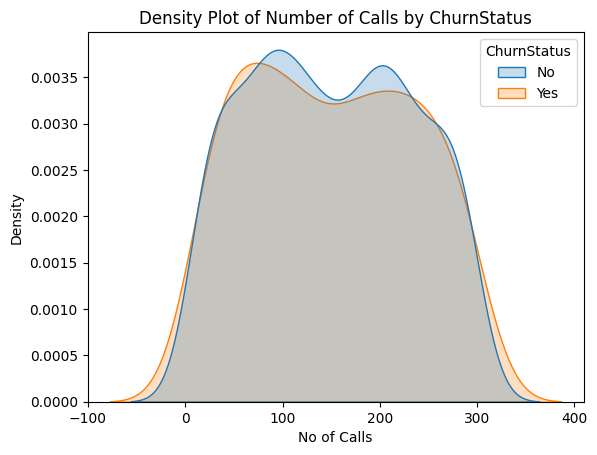

In [ ]:
sns.kdeplot(data=customer_data, x='NumberOfCalls', hue='ChurnStatus', fill=True, common_norm=False)
plt.title('Density Plot of Number of Calls by ChurnStatus')
plt.xlabel('No of Calls')
plt.ylabel('Density')
plt.show()

In [ ]:
churned_calls_mean = customer_data.loc[customer_data['ChurnStatus'] == 'Yes', 'NumberOfCalls'].mean()
not_churned_calls_mean = customer_data.loc[customer_data['ChurnStatus'] == 'No', 'NumberOfCalls'].mean()
print("Mean NumberOfCalls (Churned):", churned_calls_mean)
print("Mean NumberOfCalls (Not Churned):", not_churned_calls_mean)

Mean NumberOfCalls (Churned): 150.16744186046512
Mean NumberOfCalls (Not Churned): 150.28662420382165


In [ ]:
churned_calls = customer_data.loc[customer_data['ChurnStatus'] == 'Yes', 'NumberOfCalls']
not_churned_calls= customer_data.loc[customer_data['ChurnStatus'] == 'No', 'NumberOfCalls']

t_stat, p_val = ttest_ind(churned_calls, not_churned_calls)
print("T-stat (NumberOfCalls):", t_stat)
print("p-value (NumberOfCalls):", p_val)

T-stat (NumberOfCalls): -0.018531914923421402
p-value (NumberOfCalls): 0.985218221667676


### ChurnStatus vs MonthlyCharges

**conclusions**

* Churned customers pay about 83 dollars per month on average, while non-churned customers pay roughly 84.65 dollars.
* The t-test shows that this slight difference isn't statistically significant.
* In simple terms, monthly charges don't seem to be a key factor influencing whether a customer churns.



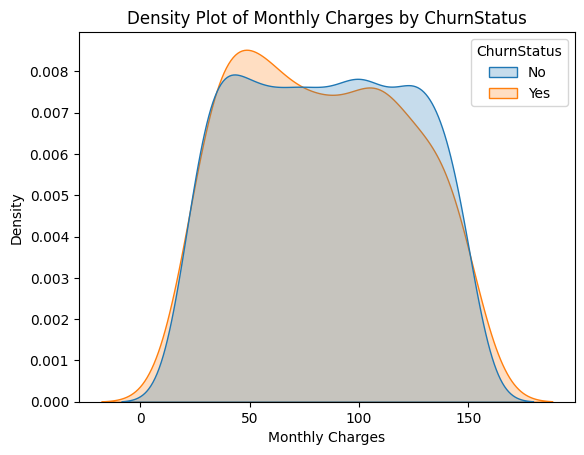

In [ ]:
sns.kdeplot(data=customer_data, x='MonthlyCharges', hue='ChurnStatus', fill=True, common_norm=False)
plt.title('Density Plot of Monthly Charges by ChurnStatus')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.show()

In [ ]:
churned_mcharges_mean = customer_data.loc[customer_data['ChurnStatus'] == 'Yes', 'MonthlyCharges'].mean()
not_churned_mcharges_mean = customer_data.loc[customer_data['ChurnStatus'] == 'No', 'MonthlyCharges'].mean()
print("Mean MonthlyCharges (Churned):", churned_mcharges_mean)
print("Mean MonthlyCharges (Not Churned):", not_churned_mcharges_mean)

Mean MonthlyCharges (Churned): 82.99741644163497
Mean MonthlyCharges (Not Churned): 84.65266779535706


In [ ]:
churned_mcharges = customer_data.loc[customer_data['ChurnStatus'] == 'Yes', 'MonthlyCharges']
not_churned_mcharges = customer_data.loc[customer_data['ChurnStatus'] == 'No', 'MonthlyCharges']

t_stat, p_val = ttest_ind(churned_mcharges , not_churned_mcharges )
print("T-stat (MonthlyCharges):", t_stat)
print("p-value (MonthlyCharges):", p_val)

T-stat (MonthlyCharges): -0.5745461935012172
p-value (MonthlyCharges): 0.5657277319872169


### Age vs. MonthlyCharges

**conclusions**

* The Pearson correlation is approximately 0.0043 which indicating almost no linear relationship between a customer's age and their monthly charges.

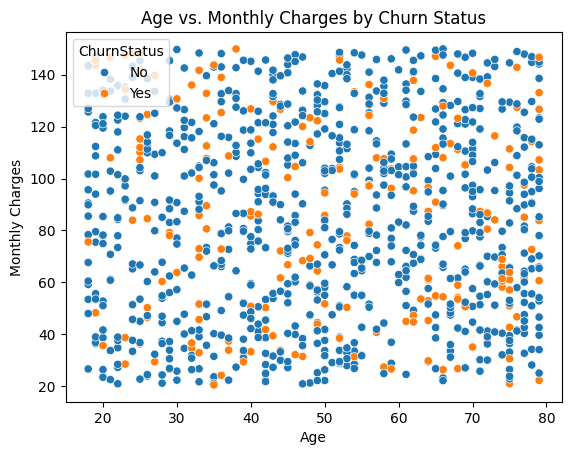

In [ ]:
sns.scatterplot(x=customer_data['Age'], y=customer_data['MonthlyCharges'], hue=customer_data['ChurnStatus'])
plt.title("Age vs. Monthly Charges by Churn Status")
plt.xlabel("Age")
plt.ylabel("Monthly Charges")
plt.show()

In [ ]:
corr_age = customer_data['Age'].corr(customer_data['MonthlyCharges'])
print("Pearson correlation (Age vs. MonthlyCharges):", corr_age)

Pearson correlation (Age vs. MonthlyCharges): 0.004329563407839593


### Age vs DataUsage

**Conclusions**

- The scatter plot of Age versus DataUsage shows a random spread with no obvious trend
- Both Pearson and Spearman correlation coefficients are very low (0.027), indicating almost no linear or monotonic relationship
- Age does not appear to have any meaningful impact on data usage
- This suggests that customer data consumption is largely independent of their age

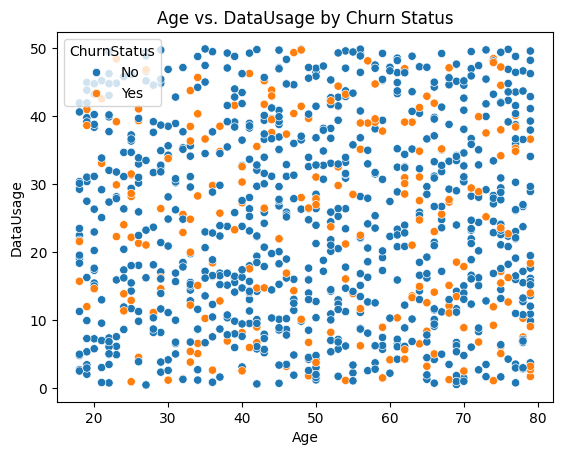

In [ ]:
sns.scatterplot(x=customer_data['Age'], y=customer_data['DataUsage'], hue=customer_data['ChurnStatus'])
plt.title("Age vs. DataUsage by Churn Status")
plt.xlabel("Age")
plt.ylabel("DataUsage")
plt.show()

In [ ]:
pearson_corr = customer_data['Age'].corr(customer_data['DataUsage'])
spearman_corr = customer_data['Age'].corr(customer_data['DataUsage'], method='spearman')
print("Pearson correlation (Age vs. DataUsage):", pearson_corr)
print("Spearman correlation (Age vs. DataUsage):", spearman_corr)

Pearson correlation (Age vs. DataUsage): 0.026645259217322893
Spearman correlation (Age vs. DataUsage): 0.026730277199124595


### AverageCallDuration vs NumberOfCalls

**conclusions**

* The scatter plot shows no clear trend between average call duration and the number of calls
* Both Pearson and Spearman correlations are nearly zero, indicating no significant linear or monotonic relationship
* This suggests that call frequency is independent of how long calls last on average

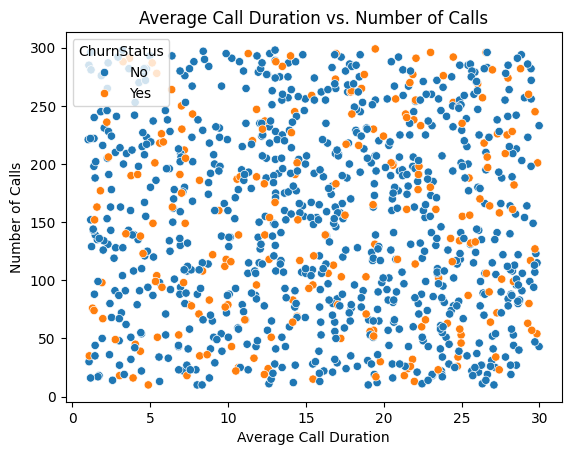

In [ ]:
sns.scatterplot(x=customer_data['AverageCallDuration'], y=customer_data['NumberOfCalls'] , hue=customer_data['ChurnStatus'])
plt.title("Average Call Duration vs. Number of Calls")
plt.xlabel("Average Call Duration")
plt.ylabel("Number of Calls")
plt.show()

In [ ]:
pearson_corr = customer_data['AverageCallDuration'].corr(customer_data['NumberOfCalls'])
spearman_corr = customer_data['AverageCallDuration'].corr(customer_data['NumberOfCalls'], method='spearman')
print("Pearson correlation (AverageCallDuration vs. NumberOfCalls):", pearson_corr)
print("Spearman correlation (AverageCallDuration vs. NumberOfCalls):", spearman_corr)

Pearson correlation (AverageCallDuration vs. NumberOfCalls): -0.016946208294673828
Spearman correlation (AverageCallDuration vs. NumberOfCalls): -0.01920992025126339


### MonthlyCharges vs DataUsage

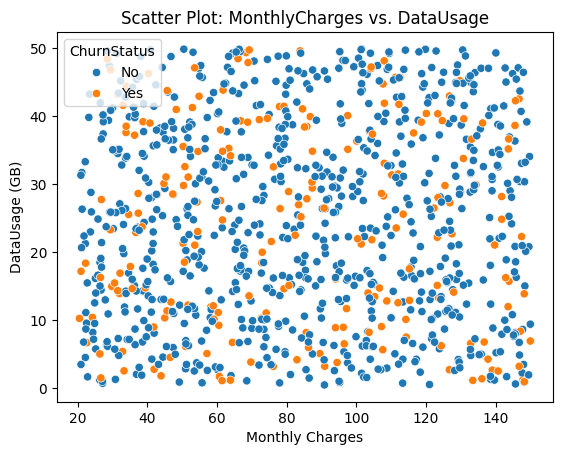

In [ ]:
sns.scatterplot(x=customer_data['MonthlyCharges'], y=customer_data['DataUsage'], hue = customer_data['ChurnStatus'])
plt.title("Scatter Plot: MonthlyCharges vs. DataUsage")
plt.xlabel("Monthly Charges")
plt.ylabel("DataUsage (GB)")
plt.show()

In [ ]:
pearson_corr = customer_data['MonthlyCharges'].corr(customer_data['DataUsage'])
spearman_corr = customer_data['MonthlyCharges'].corr(customer_data['DataUsage'], method='spearman')
print("Pearson correlation (MonthlyCharges vs. DataUsage):", pearson_corr)
print("Spearman correlation (MonthlyCharges vs. DataUsage):", spearman_corr)

Pearson correlation (MonthlyCharges vs. DataUsage): 0.03217183058521901
Spearman correlation (MonthlyCharges vs. DataUsage): 0.032138588138588144


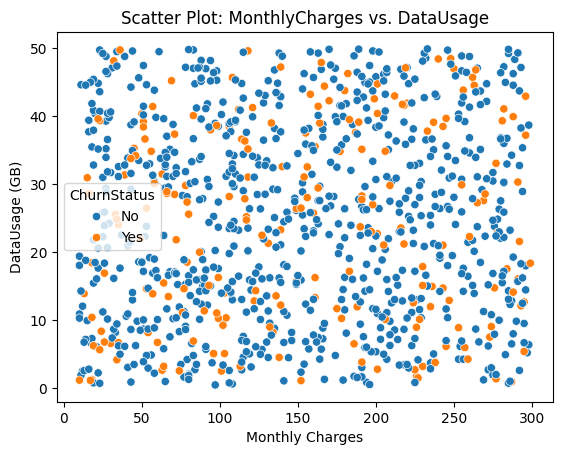

In [ ]:
sns.scatterplot(x=customer_data['NumberOfCalls'], y=customer_data['DataUsage'], hue = customer_data['ChurnStatus'])
plt.title("Scatter Plot: MonthlyCharges vs. DataUsage")
plt.xlabel("Monthly Charges")
plt.ylabel("DataUsage (GB)")
plt.show()

In [ ]:
pearson_corr = customer_data['NumberOfCalls'].corr(customer_data['DataUsage'])
spearman_corr = customer_data['NumberOfCalls'].corr(customer_data['DataUsage'], method='spearman')
print("Pearson correlation (NumberOfCalls vs. DataUsage):", pearson_corr)
print("Spearman correlation (NumberOfCalls vs. DataUsage):", spearman_corr)

Pearson correlation (NumberOfCalls vs. DataUsage): 0.03985324050049779
Spearman correlation (NumberOfCalls vs. DataUsage): 0.04079936702367526


### Performing Multivariate Analysis

**conclusions**

* Multivariate analysis confirms that no single variable or simple pairwise combination strongly differentiates churned from non-churned customers.
* It implies that the drivers of the 21% churn rate may lie in complex interactions or external factors not captured in these features

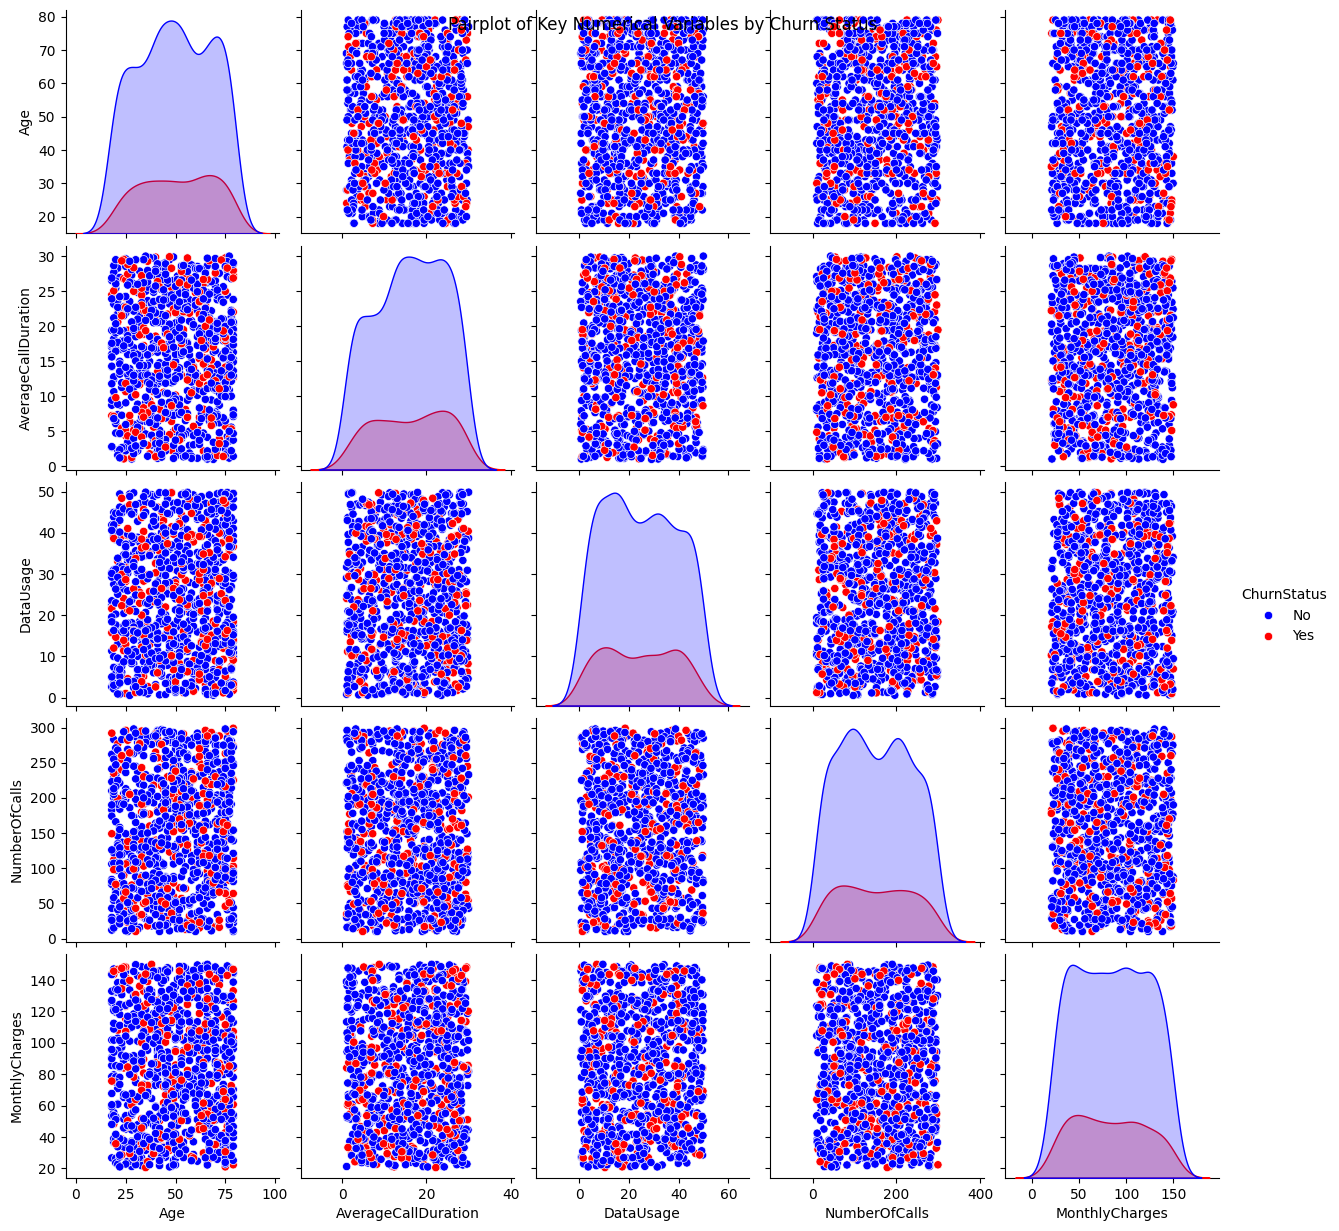

In [ ]:
cols = ['Age', 'AverageCallDuration', 'DataUsage', 'NumberOfCalls', 'MonthlyCharges']

# Create a pairplot, using ChurnStatus as hue (if it's categorical)
sns.pairplot(customer_data, vars=cols, hue='ChurnStatus', palette={'No': 'blue', 'Yes': 'red'})
plt.suptitle("Pairplot of Key Numerical Variables by Churn Status")
plt.show()

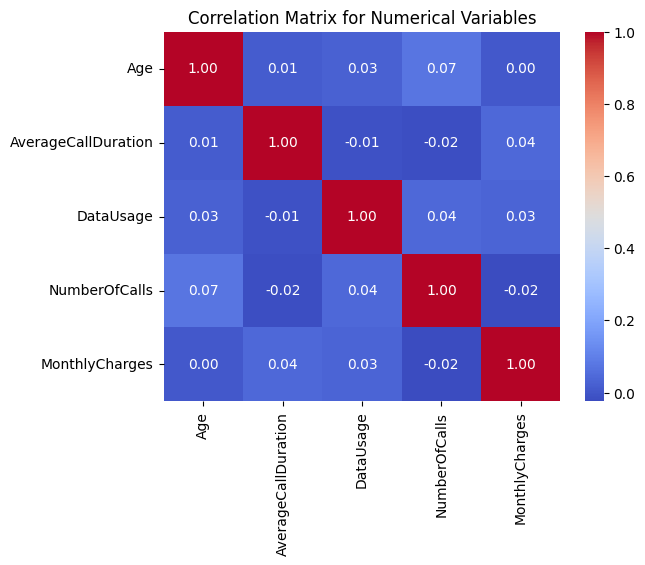

In [ ]:
# Create a correlation matrix for the selected numerical columns
corr_matrix = customer_data[cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Numerical Variables")
plt.show()

In [ ]:
plan_location = pd.crosstab(customer_data['PlanType'], customer_data['Location'], normalize='columns') * 100
print(plan_location)

Location      Rural   Suburban      Urban
PlanType                                 
Basic     73.273273  70.050761  69.787234
Premium   26.726727  29.949239  30.212766


In [ ]:
plan_churn = pd.crosstab(customer_data['PlanType'], customer_data['ChurnStatus'], normalize='index') * 100
print(plan_churn)

ChurnStatus         No        Yes
PlanType                         
Basic        78.591549  21.408451
Premium      78.275862  21.724138


### Age Group and Churn Status vs Monthly Charges

**conclusions**

* Across all age groups, monthly charges for churned vs. non-churned customers are fairly close. This suggests that age-related differences in monthly charges are not a strong driver of churn

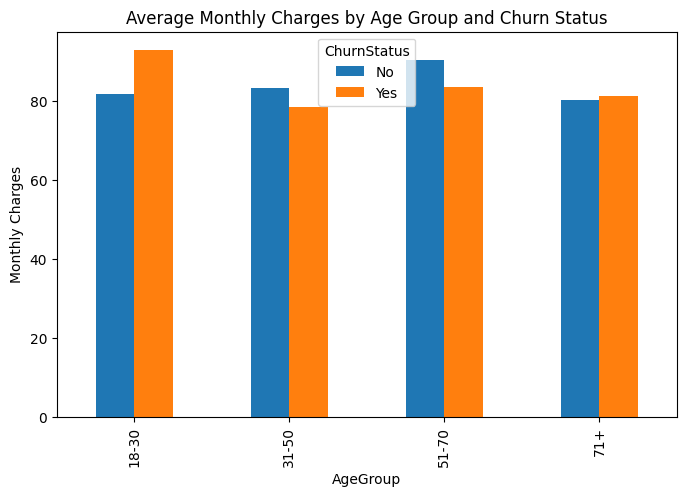

In [ ]:
bins = [18, 30, 50, 70, 100]
labels = ['18-30', '31-50', '51-70', '71+']
customer_data['AgeGroup'] = pd.cut(customer_data['Age'], bins=bins, labels=labels)

# Grouped bar chart for MonthlyCharges by AgeGroup and ChurnStatus
grouped = customer_data.groupby(['AgeGroup', 'ChurnStatus'],observed=False)['MonthlyCharges'].mean().unstack()
grouped.plot(kind='bar', figsize=(8, 5))
plt.title("Average Monthly Charges by Age Group and Churn Status")
plt.ylabel("Monthly Charges")
plt.show()
plt.show()

**conclusions**

* Performed Univariate, Bivariate and Multivate analysis on the Data but No valuable insights were found during the analysis which would give strong relation on the churn status so moving on to feature Enginnering

###Feature Engineering

In [24]:
data_fe = customer_data.copy()

### Cost Per Call

In [25]:
# Cost Per Call: MonthlyCharges divided by NumberOfCalls
data_fe['CostPerCall'] = data_fe['MonthlyCharges'] / data_fe['NumberOfCalls']

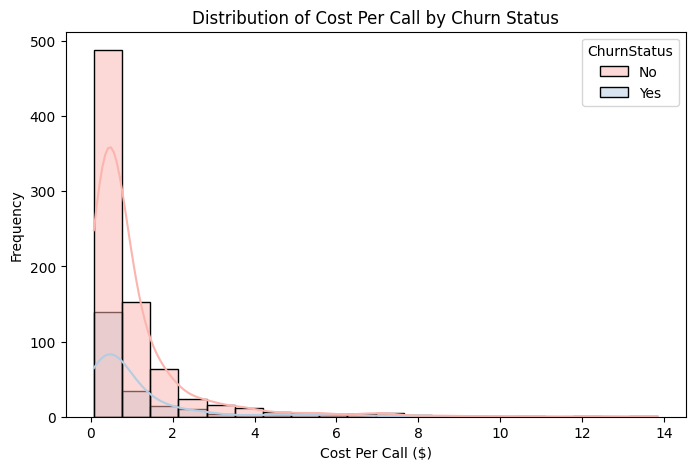

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(data=data_fe, x='CostPerCall', hue='ChurnStatus', bins=20, palette='Pastel1', kde=True)
plt.title("Distribution of Cost Per Call by Churn Status")
plt.xlabel("Cost Per Call ($)")
plt.ylabel("Frequency")
plt.show()

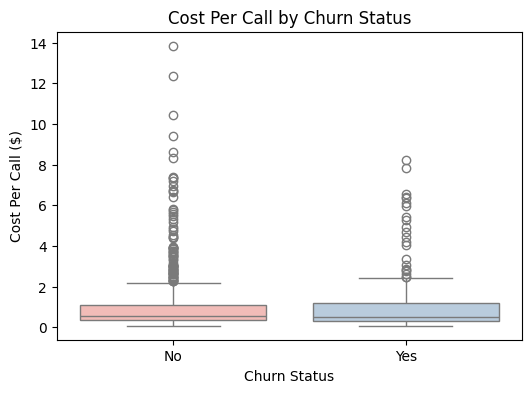

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x='ChurnStatus', y='CostPerCall', data=data_fe, hue = 'ChurnStatus', palette='Pastel1')
plt.title("Cost Per Call by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Cost Per Call ($)")
plt.show()

### Call Intensity

In [32]:
data_fe['CallIntensity'] = data_fe['NumberOfCalls'] / data_fe['Age']

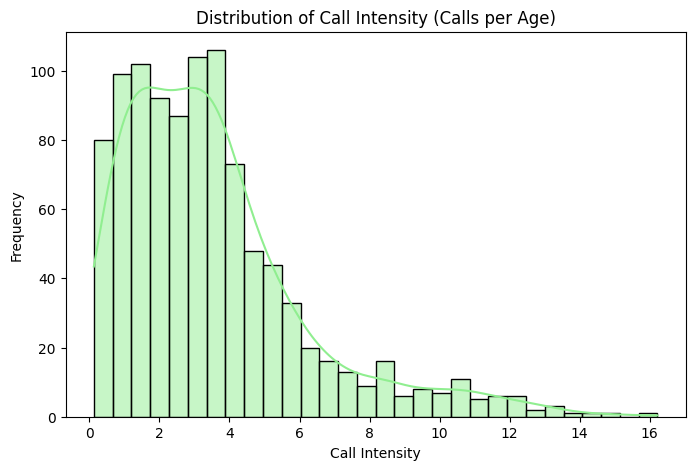

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(data_fe['CallIntensity'], kde=True, bins=30, color='lightgreen')
plt.title("Distribution of Call Intensity (Calls per Age)")
plt.xlabel("Call Intensity")
plt.ylabel("Frequency")
plt.show()

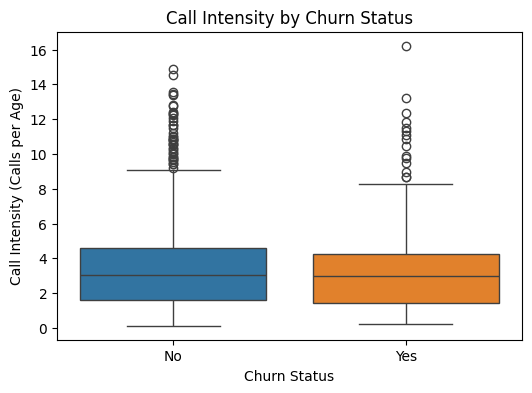

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x='ChurnStatus', y='CallIntensity', data=data_fe, hue = 'ChurnStatus')
plt.title("Call Intensity by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Call Intensity (Calls per Age)")
plt.show()

In [1]:
print(data_fe[['CostPerCall', 'CallIntensity']].describe())

NameError: name 'data_fe' is not defined

In [41]:
# Mean MonthlyCharges for churned vs. non-churned customers
mean_charges = customer_data.groupby('ChurnStatus', observed=False)['MonthlyCharges'].mean()
print("Mean Monthly Charges by Churn Status:")
print(mean_charges)

# Mean DataUsage for churned vs. non-churned customers
mean_data_usage = customer_data.groupby('ChurnStatus', observed=False)['DataUsage'].mean()
print("\nMean DataUsage by Churn Status:")
print(mean_data_usage)


Mean Monthly Charges by Churn Status:
ChurnStatus
No     84.652668
Yes    82.997416
Name: MonthlyCharges, dtype: float64

Mean DataUsage by Churn Status:
ChurnStatus
No     24.616023
Yes    24.082070
Name: DataUsage, dtype: float64


## Final Conclusion
-------------------------------------------------------------------------------
- **Key Insight:**
  * After looking at everything our original features and the ones we engineered (like CostPerCall, CallIntensity) we still don’t see any clear differences between churned and non-churned customers
  * None of these variables, either on their own or in simple combinations, seem to explain why about 21% of customers churnedd This suggests that churn might be influenced by more complex interactions or even factors we haven’t captured in our data
-------------------------------------------------------------------------------
- **Implications:**
  * This analysis is a great example of how real-world data isn’t always straightforward Even after a lot of work, sometimes you don’t find valuable insight
  * It shows that in real data analysis, getting inconclusive results is still valuable it tells us that we might need to look at interactions, bring in more data, or consider external factors.
-------------------------------------------------------------------------------
- **Next Steps:**
  - Explore more complex interactions between variables to see if these reveal subtle patterns.  
  - we can Consider collecting additional data to capture factors that might better explain the churn rate.

-------------------------------------------------------------------------------